In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

shap.initjs()
print("Libraries loaded")

Libraries loaded


In [2]:
# Load models and data
with open('models/xgb_fraud.pkl', 'rb') as f:
    xgb_fraud = pickle.load(f)

with open('models/xgb_creditcard.pkl', 'rb') as f:
    xgb_cc = pickle.load(f)

X_test_f  = pd.read_csv('data/processed/X_test_fraud.csv')
y_test_f  = pd.read_csv('data/processed/y_test_fraud.csv').squeeze()
X_test_cc = pd.read_csv('data/processed/X_test_creditcard.csv')
y_test_cc = pd.read_csv('data/processed/y_test_creditcard.csv').squeeze()

print("Models and data loaded")

Models and data loaded


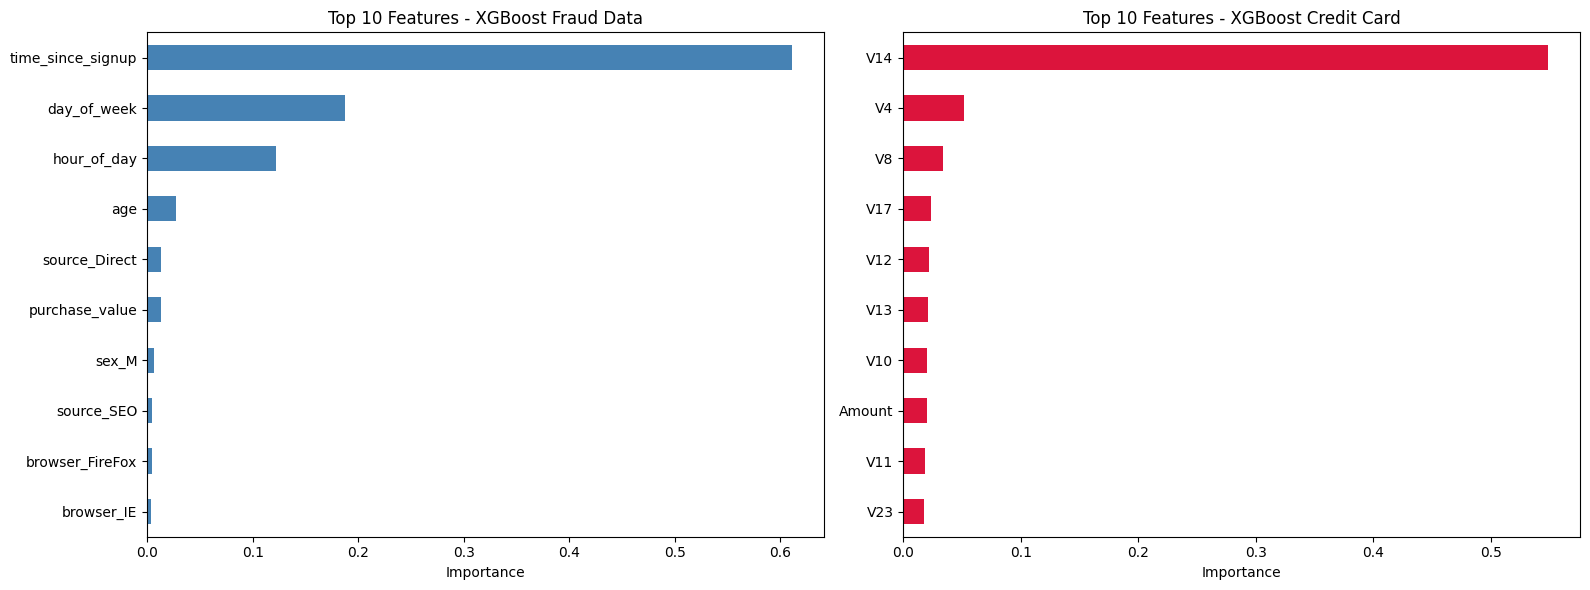

In [4]:
# Feature importance from XGBoost built-in
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Fraud data
feat_imp_f = pd.Series(xgb_fraud.feature_importances_, index=X_test_f.columns)
feat_imp_f.nlargest(10).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 Features - XGBoost Fraud Data')
axes[0].set_xlabel('Importance')

# Credit card
feat_imp_cc = pd.Series(xgb_cc.feature_importances_, index=X_test_cc.columns)
feat_imp_cc.nlargest(10).sort_values().plot(kind='barh', ax=axes[1], color='crimson')
axes[1].set_title('Top 10 Features - XGBoost Credit Card')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('data/processed/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# SHAP explainer - Fraud Data
explainer_f = shap.TreeExplainer(xgb_fraud)
shap_values_f = explainer_f.shap_values(X_test_f)
print("SHAP values computed for fraud data")
print("Shape:", shap_values_f.shape)

SHAP values computed for fraud data
Shape: (30223, 14)


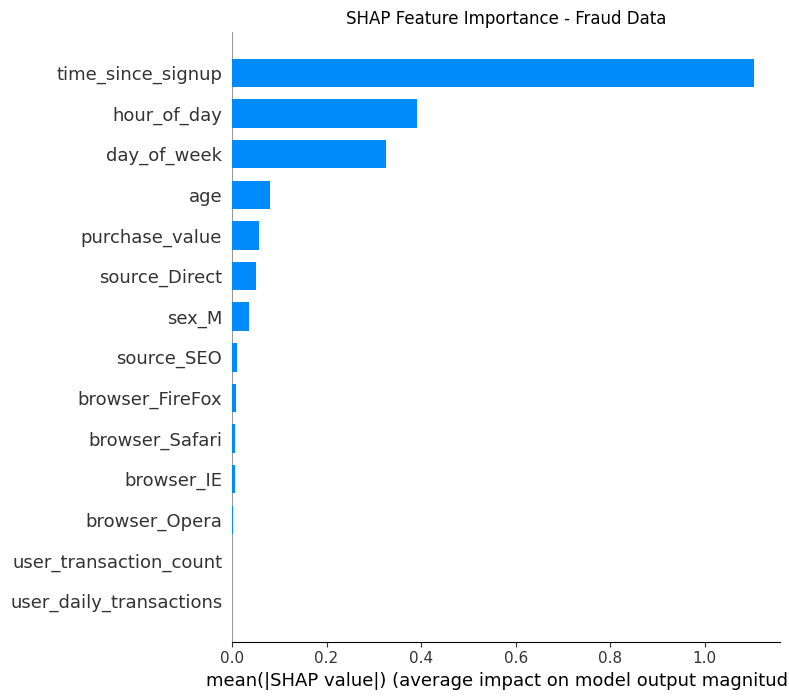

In [7]:
# SHAP Summary Plot - Fraud Data
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_f, X_test_f, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance - Fraud Data')
plt.tight_layout()
plt.savefig('data/processed/shap_summary_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

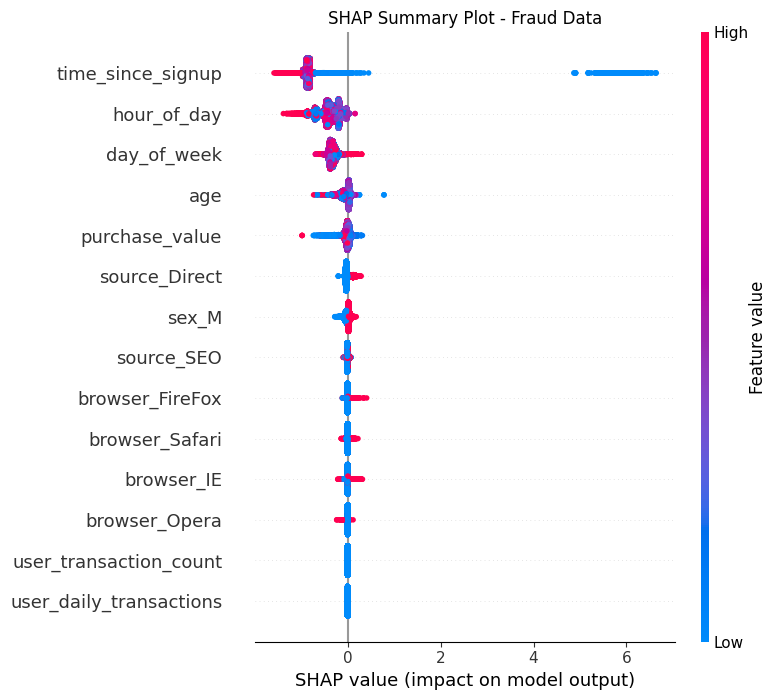

In [8]:
# SHAP Summary Plot with dots (shows direction of impact)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_f, X_test_f, max_display=15, show=False)
plt.title('SHAP Summary Plot - Fraud Data')
plt.tight_layout()
plt.savefig('data/processed/shap_summary_dots_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Find TP, FP, FN examples
y_pred_f = xgb_fraud.predict(X_test_f)

tp_idx = np.where((y_pred_f == 1) & (y_test_f.values == 1))[0][0]
fp_idx = np.where((y_pred_f == 1) & (y_test_f.values == 0))[0][0]
fn_idx = np.where((y_pred_f == 0) & (y_test_f.values == 1))[0][0]

print("True Positive index:", tp_idx)
print("False Positive index:", fp_idx)
print("False Negative index:", fn_idx)

True Positive index: 17
False Positive index: 795
False Negative index: 2


=== TRUE POSITIVE: Correctly identified fraud ===


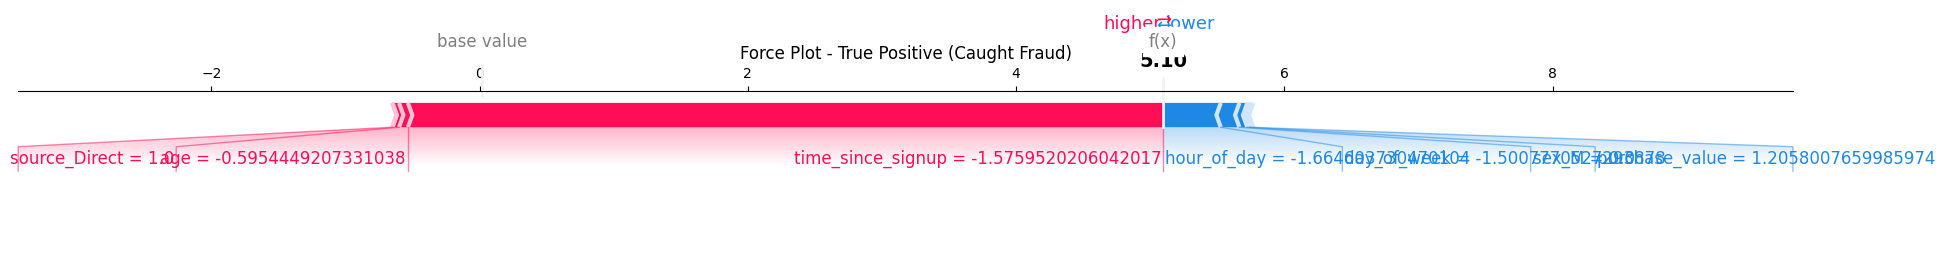

In [11]:
# Force plot - True Positive (correctly caught fraud)
print("=== TRUE POSITIVE: Correctly identified fraud ===")
shap.force_plot(
    explainer_f.expected_value,
    shap_values_f[tp_idx],
    X_test_f.iloc[tp_idx],
    matplotlib=True,
    show=False
)
plt.title('Force Plot - True Positive (Caught Fraud)')
plt.tight_layout()
plt.savefig('data/processed/shap_force_tp.png', dpi=150, bbox_inches='tight')
plt.show()

=== FALSE POSITIVE: Legitimate transaction flagged as fraud ===


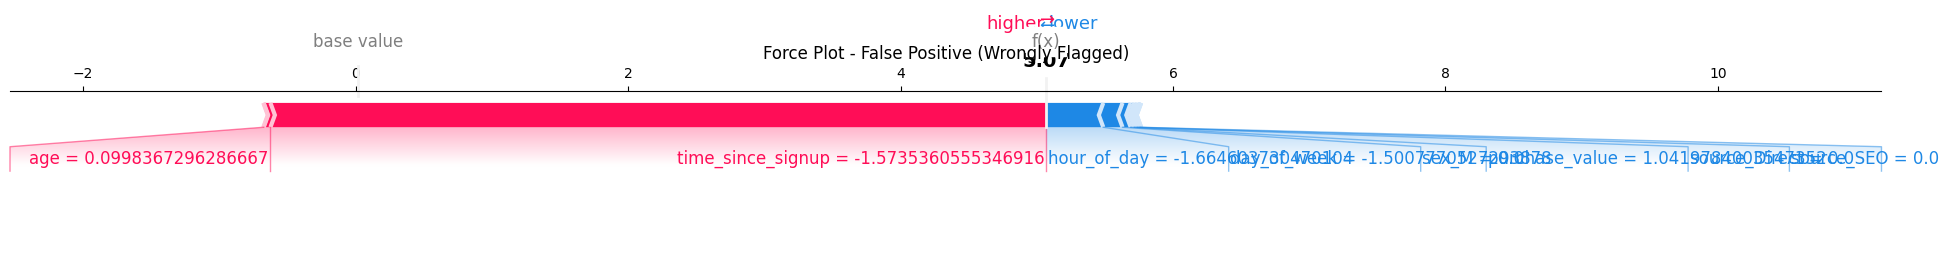

In [12]:
# Force plot - False Positive (legit flagged as fraud)
print("=== FALSE POSITIVE: Legitimate transaction flagged as fraud ===")
shap.force_plot(
    explainer_f.expected_value,
    shap_values_f[fp_idx],
    X_test_f.iloc[fp_idx],
    matplotlib=True,
    show=False
)
plt.title('Force Plot - False Positive (Wrongly Flagged)')
plt.tight_layout()
plt.savefig('data/processed/shap_force_fp.png', dpi=150, bbox_inches='tight')
plt.show()

=== FALSE NEGATIVE: Fraud that was missed ===


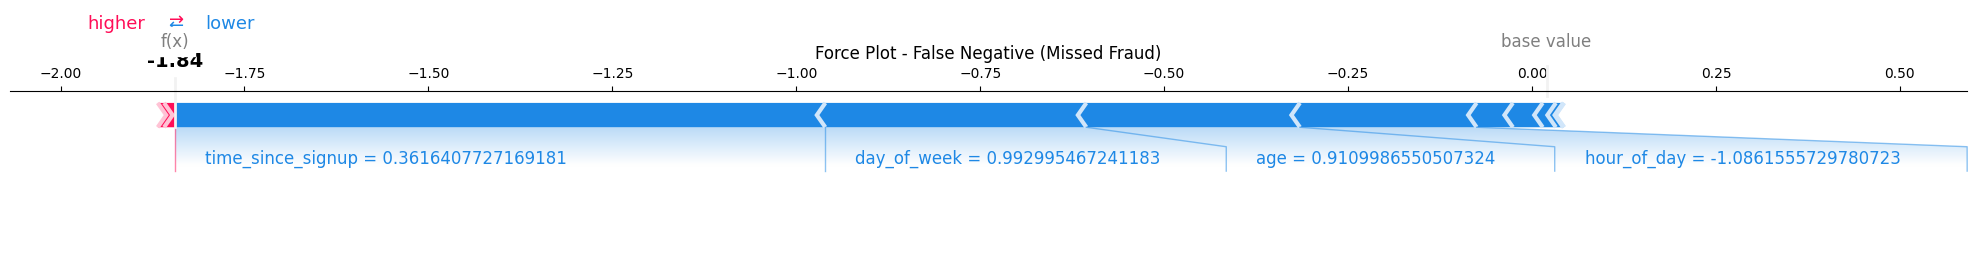

In [13]:
# Force plot - False Negative (missed fraud)
print("=== FALSE NEGATIVE: Fraud that was missed ===")
shap.force_plot(
    explainer_f.expected_value,
    shap_values_f[fn_idx],
    X_test_f.iloc[fn_idx],
    matplotlib=True,
    show=False
)
plt.title('Force Plot - False Negative (Missed Fraud)')
plt.tight_layout()
plt.savefig('data/processed/shap_force_fn.png', dpi=150, bbox_inches='tight')
plt.show()

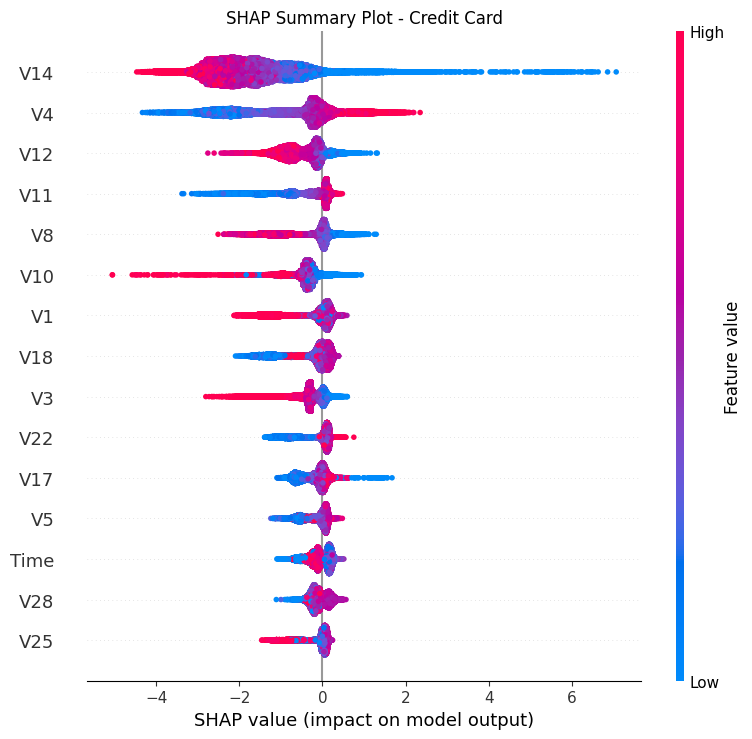

In [14]:
# SHAP for Credit Card
explainer_cc = shap.TreeExplainer(xgb_cc)
shap_values_cc = explainer_cc.shap_values(X_test_cc)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values_cc, X_test_cc, max_display=15, show=False)
plt.title('SHAP Summary Plot - Credit Card')
plt.tight_layout()
plt.savefig('data/processed/shap_summary_creditcard.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
print("""
=== BUSINESS RECOMMENDATIONS BASED ON SHAP ANALYSIS ===

1. TIME SINCE SIGNUP (top fraud driver):
   Transactions within a few hours of account signup carry 
   significantly higher fraud risk. Recommendation: Apply 
   mandatory extra verification (OTP, email confirmation) 
   for any purchase made within 24 hours of signup.

2. TRANSACTION VELOCITY (user_transaction_count):
   Users with unusually high transaction counts in short 
   periods are flagged by the model as high risk.
   Recommendation: Implement rate limiting — auto-flag 
   accounts with more than 3 transactions per hour.

3. HOUR OF DAY:
   Late night transactions (midnight to 4am) show higher 
   fraud rates. Recommendation: Apply stricter thresholds 
   during these hours or require step-up authentication.

4. PURCHASE VALUE:
   Unusually high purchase values relative to user history 
   are strong fraud signals. Recommendation: Flag 
   transactions that exceed 3x the user's average 
   purchase value for manual review.

5. COUNTRY (geolocation):
   Certain countries show consistently higher fraud rates.
   Recommendation: Apply risk scoring by country and 
   require additional verification for high-risk regions.
""")


=== BUSINESS RECOMMENDATIONS BASED ON SHAP ANALYSIS ===

1. TIME SINCE SIGNUP (top fraud driver):
   Transactions within a few hours of account signup carry 
   significantly higher fraud risk. Recommendation: Apply 
   mandatory extra verification (OTP, email confirmation) 
   for any purchase made within 24 hours of signup.

2. TRANSACTION VELOCITY (user_transaction_count):
   Users with unusually high transaction counts in short 
   periods are flagged by the model as high risk.
   Recommendation: Implement rate limiting — auto-flag 
   accounts with more than 3 transactions per hour.

3. HOUR OF DAY:
   Late night transactions (midnight to 4am) show higher 
   fraud rates. Recommendation: Apply stricter thresholds 
   during these hours or require step-up authentication.

4. PURCHASE VALUE:
   Unusually high purchase values relative to user history 
   are strong fraud signals. Recommendation: Flag 
   transactions that exceed 3x the user's average 
   purchase value for manual re

In [16]:
# Final commit reminder
print("All SHAP plots saved to data/processed/")
print("\nFiles created:")
import os
for f in os.listdir('data/processed/'):
    print(" -", f)

All SHAP plots saved to data/processed/

Files created:
 - categorical_fraud_rates.png
 - class_distribution_creditcard.png
 - class_distribution_fraud.png
 - confusion_matrices.png
 - creditcard_correlation.png
 - creditcard_distributions.png
 - distributions_fraud.png
 - engineered_features.png
 - feature_importance.png
 - fraud_by_country.png
 - fraud_data_with_country.csv
 - model_comparison.csv
 - precision_recall_curves.png
 - shap_force_fn.png
 - shap_force_fp.png
 - shap_force_tp.png
 - shap_summary_creditcard.png
 - shap_summary_dots_fraud.png
 - shap_summary_fraud.png
 - smote_comparison.png
 - smote_creditcard.png
 - X_test_creditcard.csv
 - X_test_fraud.csv
 - X_train_creditcard.csv
 - X_train_fraud.csv
 - y_test_creditcard.csv
 - y_test_fraud.csv
 - y_train_creditcard.csv
 - y_train_fraud.csv
